# Notebook 1 — System Overview & Data Loading

This notebook introduces the **Spot Semantic Mapping** system and walks through how
raw RGB-D sensor data is loaded and preprocessed before any inference.

---

## Prerequisites

| Topic | Why it matters |
|-------|---------------|
| Python / NumPy | All data is represented as NumPy arrays |
| Basic linear algebra | Camera projection uses 3×3 and 4×4 matrices |
| RGB-D cameras | The system ingests colour + depth images |
| YAML configuration | System behaviour is controlled through `main_config.yml` |

> **Not required:** deep learning, 3D geometry (covered in later notebooks).

---

## Learning Objectives

After this notebook you will be able to:

1. Describe the end-to-end pipeline at a high level.
2. Load the system configuration.
3. Read a Spot recording or an iPhone RGB-D sequence.
4. Understand camera intrinsics and SE(3) camera poses.
5. Visualise a trajectory and a raw RGB-D frame pair.

## 1 · System Architecture

The figure below shows how data flows through the pipeline.

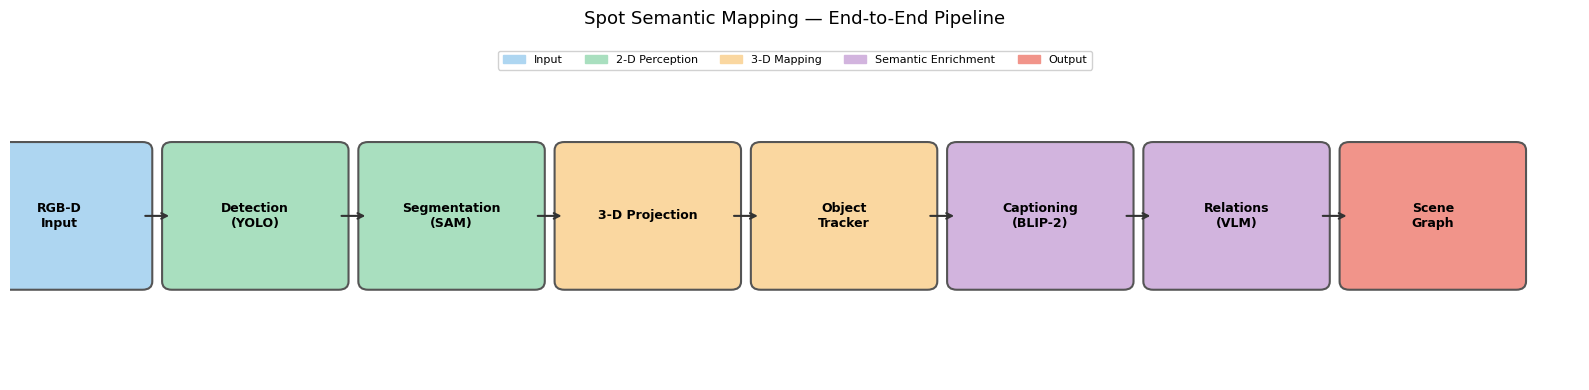

In [2]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyArrowPatch

fig, ax = plt.subplots(figsize=(16, 4))
ax.set_xlim(0, 16); ax.set_ylim(0, 4); ax.axis('off')

stages = [
    ("RGB-D\nInput",        0.5,  "#AED6F1"),
    ("Detection\n(YOLO)",   2.5,  "#A9DFBF"),
    ("Segmentation\n(SAM)", 4.5,  "#A9DFBF"),
    ("3-D Projection",       6.5,  "#FAD7A0"),
    ("Object\nTracker",     8.5,  "#FAD7A0"),
    ("Captioning\n(BLIP-2)",10.5, "#D2B4DE"),
    ("Relations\n(VLM)",   12.5,  "#D2B4DE"),
    ("Scene\nGraph",       14.5,  "#F1948A"),
]

for label, x, colour in stages:
    ax.add_patch(mpatches.FancyBboxPatch(
        (x-0.85, 1.2), 1.7, 1.6, boxstyle="round,pad=0.1",
        facecolor=colour, edgecolor='#555', linewidth=1.5))
    ax.text(x, 2.0, label, ha='center', va='center', fontsize=9, fontweight='bold')

for i in range(len(stages)-1):
    x0 = stages[i][1] + 0.85
    x1 = stages[i+1][1] - 0.85
    ax.annotate('', xy=(x1, 2.0), xytext=(x0, 2.0),
                arrowprops=dict(arrowstyle='->', lw=1.5, color='#333'))

legend_patches = [
    mpatches.Patch(color='#AED6F1', label='Input'),
    mpatches.Patch(color='#A9DFBF', label='2-D Perception'),
    mpatches.Patch(color='#FAD7A0', label='3-D Mapping'),
    mpatches.Patch(color='#D2B4DE', label='Semantic Enrichment'),
    mpatches.Patch(color='#F1948A', label='Output'),
]
ax.legend(handles=legend_patches, loc='upper center', bbox_to_anchor=(0.5, 1.02),
          ncol=5, fontsize=8, framealpha=0.9)
ax.set_title('Spot Semantic Mapping — End-to-End Pipeline', fontsize=13, pad=20)
plt.tight_layout()
plt.show()

### Pipeline summary

| Stage | Module | What it does |
|-------|--------|-------------|
| **RGB-D Input** | `spot/dataset.py`, `core/io.py` | Load colour + depth frames and odometry |
| **Detection** | `models/detection.py` | YOLO open-world bounding boxes |
| **Segmentation** | `models/segmentation.py` | SAM2 pixel masks from bounding boxes |
| **3-D Projection** | `mapping/pipeline.py` | Back-project masked pixels into a point cloud |
| **Object Tracker** | `mapping/tracker.py` | Match new detections to existing 3-D objects |
| **Captioning** | `models/captioning.py` | BLIP-2 multi-view caption for each object |
| **Relations** | `mapping/relations.py` | Spatial edges via VLM voting |
| **Scene Graph** | `core/types.py` | JSON export with objects + typed edges |

Notebooks 2–4 go deep on each coloured group.

## 2 · Configuration

All model paths, thresholds, and runtime flags live in a single YAML file loaded through a `Config` singleton.

In [3]:
from spot_semantic_mapping.configs.loader import cfg

# The config object behaves like a nested dict
print("Device :", cfg.device)
print("Detector:", cfg.segmentation['detector'])
print("SAM backend:", cfg.segmentation['sam_backend'])
print("Tracking weights — geometric:", cfg.tracking['w_geo'],
      "  semantic:", cfg.tracking['w_sem'])
print("VPR aggregation:", cfg.vpr['agg_method'],
      "  clusters:", cfg.vpr['num_clusters'])

Device : cuda
Detector: yolov8
SAM backend: sam2
Tracking weights — geometric: 1   semantic: 1
VPR aggregation: vlad   clusters: 32


> **Design note:** a single config file means every experiment is reproducible —
> you only need to version `main_config.yml` alongside your code.

Key sections you will touch in later notebooks:

```
segmentation.detector       – yolov8 | yolov11
segmentation.sam_backend    – sam2 | mobilesam | fastsam
tracking.w_geo / w_sem      – geometry vs. semantics balance
vpr.agg_method              – vlad | domain_vlad | gmp | gap | gem
pipeline.use_every_n_frames – speed vs. coverage trade-off
```

## 3 · Data Sources

The system supports two sensor platforms.

| Platform | Format | Depth source | Typical resolution |
|----------|--------|--------------|--------------------|
| **Boston Dynamics Spot** | Proprietary binary frames | Structured-light stereo | 640 × 480 depth, 1280 × 720 RGB |
| **iPhone LiDAR** | Stray Scanner export | LiDAR ToF | 256 × 192 depth, 1920 × 1440 RGB |

Both share the same downstream pipeline after loading.

### 3a · Spot Dataset

In [4]:
from spot_semantic_mapping.spot.dataset import SpotDataset

# Update this path to your Spot recording directory
DATASET_PATH = '../data/spot/millerst/data'

ds = SpotDataset(DATASET_PATH)
print(f'Loaded {len(ds)} sequences')

# Inspect a single sample
sample = ds[0]
print('\nSample fields:', list(vars(sample).keys()))
print('Cameras available:', list(sample.cameras.keys()))

cam_name = list(sample.cameras.keys())[0]
frame = sample.cameras[cam_name]
print(f'\nCamera: {cam_name}')
print(f'  RGB shape : {frame.image.shape}')
print(f'  Intrinsics: fx={frame.intr.fx:.1f}  fy={frame.intr.fy:.1f}'
      f'  cx={frame.intr.cx:.1f}  cy={frame.intr.cy:.1f}')

Loaded 214 sequences

Sample fields: ['timestamp', 'odom_T_body', 'cameras']
Cameras available: ['back_depth_in_visual_frame', 'back_fisheye_image', 'frontleft_depth_in_visual_frame', 'frontleft_fisheye_image', 'frontright_depth_in_visual_frame', 'frontright_fisheye_image', 'hand_color_image', 'hand_color_in_hand_depth_frame', 'hand_depth', 'hand_depth_in_hand_color_frame', 'left_depth_in_visual_frame', 'left_fisheye_image', 'right_depth_in_visual_frame', 'right_fisheye_image']

Camera: back_depth_in_visual_frame
  RGB shape : (480, 640)
  Intrinsics: fx=257.1  fy=256.6  cx=322.8  cy=248.6


### 3b · iPhone RGB-D (Stray Scanner)

In [5]:
import os
import numpy as np
from spot_semantic_mapping.core.io import load_intrinsics, load_poses

# Update to your iPhone RGBD sequence directory
IPHONE_PATH = '../data/iphone/3578aa5730'

intrinsics = load_intrinsics(
    os.path.join(IPHONE_PATH, 'camera_matrix.csv'),
    scale_x=cfg.camera['depth_width']  / cfg.camera['rgb_width'],
    scale_y=cfg.camera['depth_height'] / cfg.camera['rgb_height'],
)
poses = load_poses(os.path.join(IPHONE_PATH, 'odometry.csv'))

print('Intrinsics:', intrinsics)
print(f'Loaded {len(poses)} poses')
print('First pose (T_WC):')
print(np.round(poses[0], 4))

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.
Intrinsics: {'fx': 201.9324, 'fy': 201.9324, 'cx': 128.23405733333334, 'cy': 95.84038133333334}
Loaded 15811 poses
First pose (T_WC):
[[-0.0924 -0.9955 -0.0189  0.    ]
 [-0.6006  0.0708 -0.7964  0.    ]
 [ 0.7942 -0.0622 -0.6045  0.    ]
 [ 0.      0.      0.      1.    ]]


## 4 · Camera Intrinsics & the Pinhole Model

Before we can lift 2-D pixels to 3-D space we need the **camera intrinsics** — the four
numbers that describe how the lens maps the 3-D world onto the image plane.

$$
\begin{pmatrix} u \\ v \\ 1 \end{pmatrix}
=
\underbrace{\begin{pmatrix} f_x & 0 & c_x \\ 0 & f_y & c_y \\ 0 & 0 & 1 \end{pmatrix}}_{K}
\begin{pmatrix} X/Z \\ Y/Z \\ 1 \end{pmatrix}
$$

| Symbol | Meaning |
|--------|---------|
| $f_x, f_y$ | Focal lengths in pixels |
| $c_x, c_y$ | Principal point (optical axis in image coordinates) |
| $u, v$ | Pixel coordinates |
| $X, Y, Z$ | 3-D point in camera frame |

The **back-projection** (pixel + depth → 3-D) inverts this:

$$
X = (u - c_x) \cdot Z / f_x, \quad Y = (v - c_y) \cdot Z / f_y
$$

## 5 · SE(3) Poses

Each frame comes with a **pose matrix** $T_{WC} \in SE(3)$ that encodes where the
camera was in the world when that frame was captured.

$$
T_{WC} = \begin{pmatrix} R & \mathbf{t} \\ \mathbf{0}^\top & 1 \end{pmatrix}
\in \mathbb{R}^{4 \times 4}
$$

- $R \in SO(3)$ — 3×3 rotation matrix  
- $\mathbf{t} \in \mathbb{R}^3$ — translation (camera position in world frame)

> **Convention:** $T_{WC}$ transforms a point from *camera* frame to *world* frame.
> Subscripts read right-to-left: "C expressed in W".

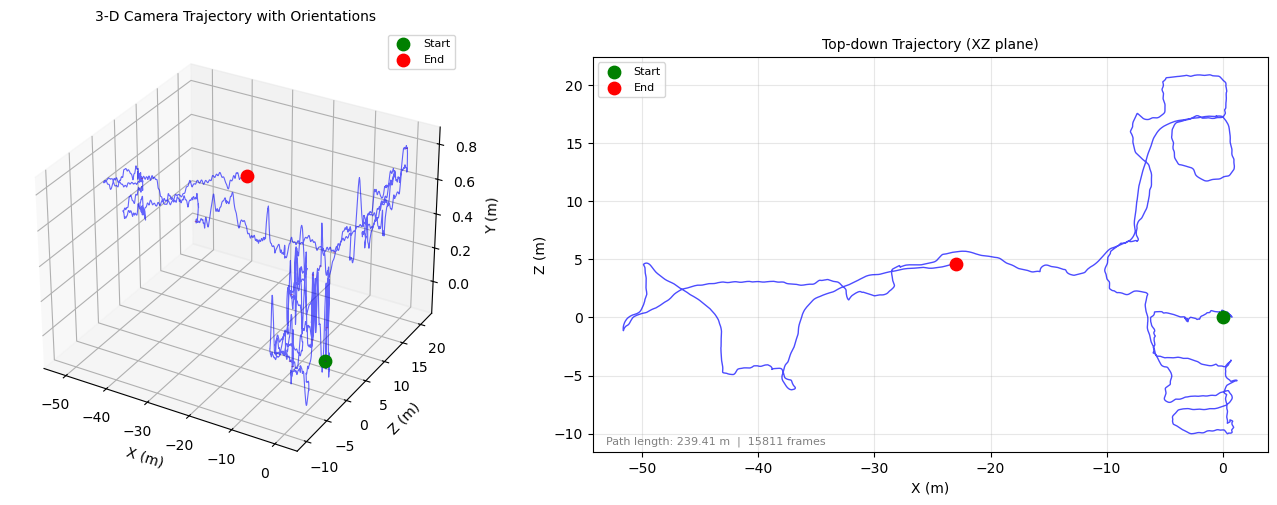

In [7]:
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.mplot3d import Axes3D  # noqa

poses = load_poses(os.path.join(IPHONE_PATH, 'odometry.csv'))
positions = np.array([T[:3, 3] for T in poses])   # (N, 3)  x, y, z

fig = plt.figure(figsize=(14, 5))

# ── Left: 3-D trajectory ─────────────────────────────────────────────────────
ax3d = fig.add_subplot(121, projection='3d')
ax3d.plot(positions[:, 0], positions[:, 2], positions[:, 1],
          'b-', lw=0.8, alpha=0.6)
ax3d.scatter(*positions[0, [0,2,1]],  color='green', s=80, label='Start', zorder=5)
ax3d.scatter(*positions[-1, [0,2,1]], color='red',   s=80, label='End',   zorder=5)

# Draw a few camera axes to show orientation
step = max(1, len(poses)//12)
for T in poses[::step]:
    o = T[:3, 3]
    for col, col_idx in [('r',0),('g',1),('b',2)]:
        d = T[:3, col_idx] * 0.05
        ax3d.quiver(o[0], o[2], o[1], d[0], d[2], d[1],
                    color=col, alpha=0.6, length=0.04, normalize=False)

ax3d.set_xlabel('X (m)'); ax3d.set_ylabel('Z (m)'); ax3d.set_zlabel('Y (m)')
ax3d.set_title('3-D Camera Trajectory with Orientations', fontsize=10)
ax3d.legend(fontsize=8)

# ── Right: top-down XZ view ───────────────────────────────────────────────────
ax2d = fig.add_subplot(122)
ax2d.plot(positions[:, 0], positions[:, 2], 'b-', lw=1, alpha=0.7)
ax2d.scatter(positions[0, 0],  positions[0, 2],  c='green', s=80, zorder=5, label='Start')
ax2d.scatter(positions[-1, 0], positions[-1, 2], c='red',   s=80, zorder=5, label='End')
ax2d.set_xlabel('X (m)'); ax2d.set_ylabel('Z (m)')
ax2d.set_title('Top-down Trajectory (XZ plane)', fontsize=10)
ax2d.set_aspect('equal'); ax2d.legend(fontsize=8); ax2d.grid(True, alpha=0.3)

total_dist = np.sum(np.linalg.norm(np.diff(positions, axis=0), axis=1))
ax2d.text(0.02, 0.02, f'Path length: {total_dist:.2f} m  |  {len(poses)} frames',
          transform=ax2d.transAxes, fontsize=8, color='grey')

plt.tight_layout()
plt.show()

## 6 · Loading an RGB-D Frame

Each frame consists of a colour image, a depth image, and (optionally) a confidence map.

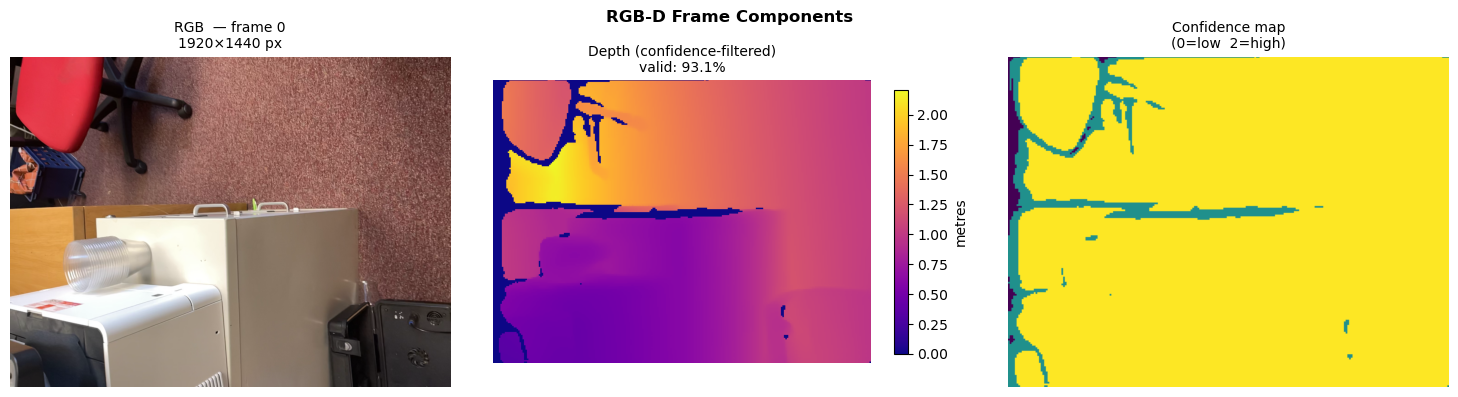

RGB   shape: (1440, 1920, 3)    dtype: uint8
Depth shape: (192, 256)  dtype: float32
Depth range: [0.336, 2.209] m


In [8]:
import matplotlib.pyplot as plt
from PIL import Image
from spot_semantic_mapping.core.io import load_depth, load_conf
import skvideo.io

np.int   = np.int_       # NumPy 2.x compat shim
np.float = np.float64

FRAME_IDX = 0

conf  = load_conf(os.path.join(IPHONE_PATH, 'confidence', f'{FRAME_IDX:06d}.png'))
depth = load_depth(
    os.path.join(IPHONE_PATH, 'depth', f'{FRAME_IDX:06d}.png'),
    conf,
    filter_level=cfg.projection['min_confidence'],
)
video = skvideo.io.vreader(os.path.join(IPHONE_PATH, 'rgb.mp4'))
rgb   = next(iter(video))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].imshow(rgb)
axes[0].set_title(f'RGB  — frame {FRAME_IDX}\n{rgb.shape[1]}×{rgb.shape[0]} px', fontsize=10)
axes[0].axis('off')

im = axes[1].imshow(depth, cmap='plasma',
                    vmin=0, vmax=depth[depth > 0].max())
axes[1].set_title(f'Depth (confidence-filtered)\nvalid: {(depth>0).mean()*100:.1f}%', fontsize=10)
axes[1].axis('off')
plt.colorbar(im, ax=axes[1], label='metres', shrink=0.8)

if conf is not None:
    axes[2].imshow(conf, cmap='viridis')
    axes[2].set_title('Confidence map\n(0=low  2=high)', fontsize=10)
    axes[2].axis('off')
else:
    axes[2].axis('off')
    axes[2].text(0.5, 0.5, 'No confidence map\n(Spot sensor)',
                 ha='center', va='center', transform=axes[2].transAxes)

plt.suptitle('RGB-D Frame Components', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'RGB   shape: {rgb.shape}    dtype: {rgb.dtype}')
print(f'Depth shape: {depth.shape}  dtype: {depth.dtype}')
print(f'Depth range: [{depth[depth>0].min():.3f}, {depth[depth>0].max():.3f}] m')

## Summary

| Concept | Key takeaway |
|---------|-------------|
| **Config** | Single YAML file controls all models and thresholds |
| **Spot dataset** | Binary frame files, multi-camera, direct SDK integration |
| **iPhone dataset** | Stray Scanner export — CSV odometry + PNG depth + MP4 colour |
| **Intrinsics K** | 4 numbers $(f_x, f_y, c_x, c_y)$ link pixel coordinates to 3-D space |
| **Pose $T_{WC}$** | 4×4 SE(3) matrix: rotation + translation of camera in world frame |
| **Depth filtering** | Confidence map removes unreliable LiDAR returns |

**Next:** Notebook 2 runs YOLO detection and SAM segmentation on the RGB frame.